<div style="border:1px solid #d8e2ef; border-radius:18px; padding:26px 30px; background:#ffffff;">
  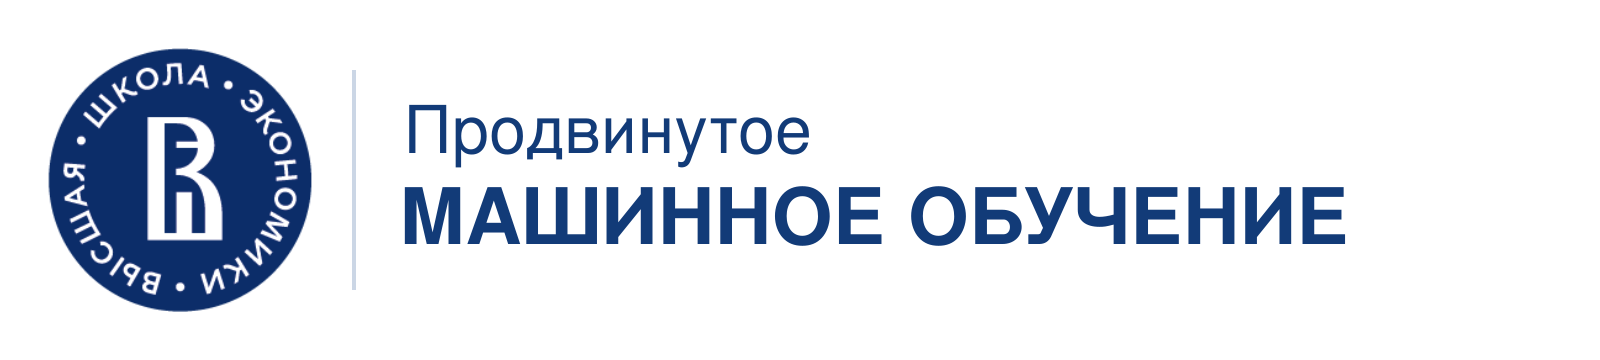

# Семинар №1-2
## Решающие деревья и ансамбли
### Credits for the seminar: [ML курс Евгения Соколова](https://github.com/esokolov/ml-course-hse/blob/master/ml1-2026-spring/seminars/sem09-trees.ipynb)
</div>

## Часть I. Решающие деревья

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from sklearn.datasets import load_iris, load_wine
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree

plt.rcParams.update({"font.size": 12, "axes.titlesize": 14, "figure.dpi": 110})
class_colors = ["#e58139", "#39e581", "#8139e5"]
class_cmap = ListedColormap(class_colors)

### 1. Как работает дерево

Во внутренней вершине проверяем условие, например «длина лепестка не больше 2.45 см». Если условие выполнено, идём влево; иначе — вправо. Повторяем проверки, пока не попадём в **лист**, где записан прогноз.

Начнём с Iris: 150 цветов, три вида. Возьмём два признака — длину и ширину лепестка — и посмотрим, какие области выделяет дерево. Здесь используем все объекты, чтобы разобрать устройство модели; качество на новых данных оценим позже, с отдельной validation-выборкой.

### Как строится график границ решений

1. **Обучаем модель:** `tree_iris.fit(X_iris, y_iris)`
    - Дерево обучается на 150 реальных цветках и подбирает пороги вида «признак ≤ порог».

2. **Создаём сетку:** `np.linspace` + `np.meshgrid`
    - Получаем 250 × 250 = 62 500 точек, равномерно покрывающих область данных с небольшим запасом.
    - Сетка не берётся из модели и не является результатом обучения. Это просто координаты, которые мы задаём сами.

3. **Предсказываем класс для каждой точки сетки:** `tree_iris.predict(np.c_[g1.ravel(), g2.ravel()])`
    - `ravel` и `np.c_` превращают сетку в массив формы (62500, 2).
    - Модель присваивает каждой точке класс 0, 1 или 2.
    - `reshape(g1.shape)` возвращает результат к форме 250 × 250.

4. **Закрашиваем области по предсказаниям:** `plt.contourf(...)`
    - Цвет фона показывает, какой класс модель предскажет для любой комбинации длины и ширины лепестка.

5. **Рисуем поверх реальные данные:** `plt.scatter(...)`
    - 150 настоящих цветков с их **истинными** классами.
    - Точки рисуются после заливки, поэтому оказываются сверху.

**Как читать график:** если цвет точки совпадает с цветом фона под ней, модель классифицирует этот цветок верно. Если не совпадает, модель ошибается.

> **Важно:** точки на графике — это обучающие данные. График показывает, как модель подстроилась под них, но не говорит о качестве на новых цветках. Для этого нужна отложенная выборка (`train_test_split`).

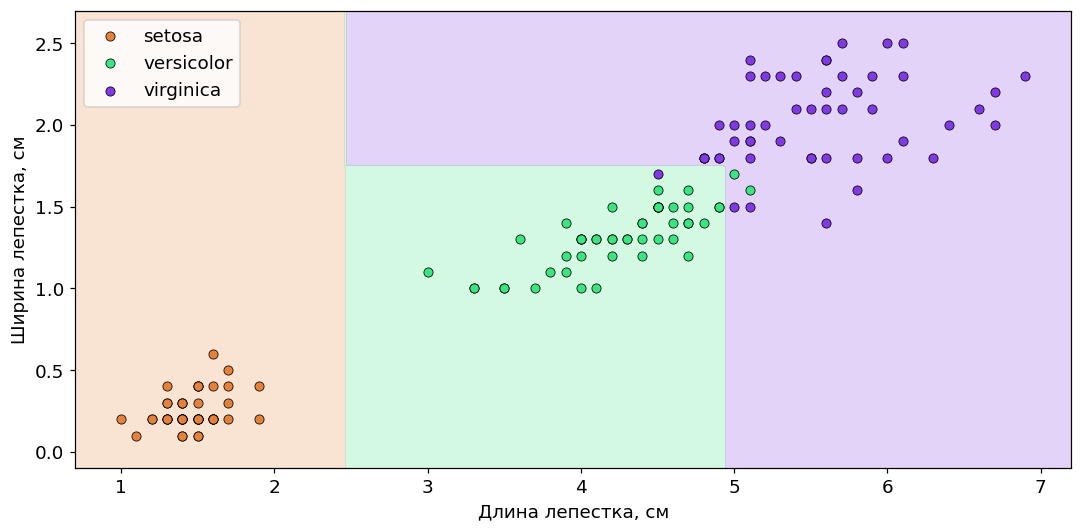

In [ ]:
iris = load_iris()
X_iris, y_iris = iris.data[:, 2:], iris.target # все объекты, но берем только две фичи: ширину и длину лепестка
tree_iris = DecisionTreeClassifier(max_depth=3, random_state=42, criterion="gini") # здесь можно выбрать критерий (criterion=)
tree_iris.fit(X_iris, y_iris)

x1 = np.linspace(X_iris[:, 0].min() - 0.3, X_iris[:, 0].max() + 0.3, 250) # создаем сетку из 62500 точек (ирисов), чтобы воспользоваться обученной моделью и разделить область
x2 = np.linspace(X_iris[:, 1].min() - 0.2, X_iris[:, 1].max() + 0.2, 250)
g1, g2 = np.meshgrid(x1, x2)
prediction = tree_iris.predict(np.c_[g1.ravel(), g2.ravel()]).reshape(g1.shape) # делаем предикт моделью для новых данных, разделяя область
# ravel - это то же самое, что и flatten, но не создает копию массива, разворачивая его

plt.figure(figsize=(10, 5))
plt.contourf(g1, g2, prediction, levels=[-0.5, 0.5, 1.5, 2.5],
             cmap=class_cmap, alpha=0.22)
for k, color in enumerate(class_colors):
    plt.scatter(X_iris[y_iris == k, 0], X_iris[y_iris == k, 1],
                color=color, edgecolor="black", linewidth=0.5,
                label=iris.target_names[k])
plt.xlabel("Длина лепестка, см")
plt.ylabel("Ширина лепестка, см")
plt.legend()
plt.tight_layout()
plt.show()

Ниже — схема **того же дерева**. Границы на предыдущем графике параллельны осям, потому что одна проверка использует один признак.

На схеме `samples` — число обучающих объектов в вершине, `value` — их количества по классам, `class` — выбранный класс. Проследите путь для цветка с длиной лепестка **5 см** и шириной **1.5 см**. Какой класс получится?

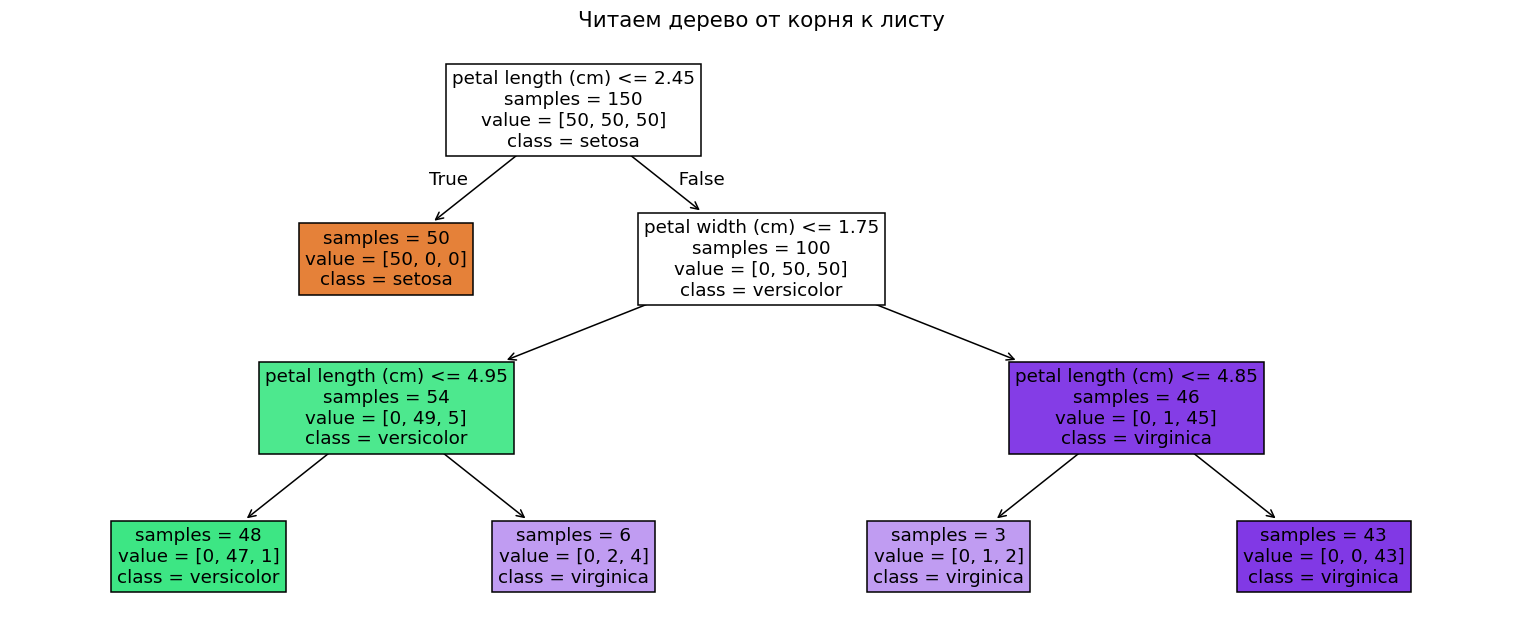

In [ ]:
plt.figure(figsize=(14, 6))
plot_tree(tree_iris, feature_names=iris.feature_names[2:],
          class_names=iris.target_names, filled=True,
          impurity=False, fontsize=12)
plt.title("Читаем дерево от корня к листу")
plt.tight_layout()
plt.show()

### 2. Что предсказываем в листе

Все объекты одного листа получают один и тот же прогноз. Его выбирают по обучающим объектам, попавшим в этот лист.

- **Регрессия с квадратичной ошибкой:** предсказываем среднее значение целевой переменной.
- **Классификация:** предсказываем самый частый класс. `predict_proba` возвращает доли классов: например, для меток $(1,1,2,2,2,2)$ это $1/3$ и $2/3$, а `predict` выбирает класс 2.

Обозначим через $R$ объекты листа, через $n$ — их число, а через $y_i$ — известные целевые значения. Для регрессии:

$$
\large
\widehat y_R=\bar y_R=\frac1n\sum_{i\in R}y_i.
$$

**Откуда берётся среднее?** Это постоянное число, при котором сумма квадратов ошибок на объектах листа минимальна. После выбора среднего считаем саму ошибку:

$$
\large
H_{\mathrm{MSE}}(R)=\frac1n\sum_{i\in R}(y_i-\bar y_R)^2.
$$

MSE показывает, насколько сильно значения $y$ разбросаны вокруг прогноза листа. Если они одинаковые, MSE равна нулю. Крупные отклонения штрафуются сильнее из-за квадрата. Делим на $n$, поскольку считаем среднюю ошибку на этих объектах.

Например, для значений $2,3,4$ прогноз равен $3$, а MSE — $(1+0+1)/3=2/3$. Проверим:

In [ ]:
y_leaf = np.array([2., 3., 4.])
leaf_prediction = y_leaf.mean()
squared_errors = (y_leaf - leaf_prediction) ** 2
print("Прогноз листа:", leaf_prediction)
print("Квадраты ошибок:", squared_errors)
print(f"MSE: {squared_errors.mean():.3f}")

Прогноз листа: 3.0
Квадраты ошибок: [1. 0. 1.]
MSE: 0.667


### Почему MSE дешевле MAE при построении дерева

**Контекст.** В каждом узле дерево ищет лучший порог. Объекты сортируются по признаку, и перебираются пороги между соседними значениями. При сдвиге порога на одну позицию **ровно один объект** переходит из правой части в левую. Для каждого порога считается сумма ошибки слева и ошибки справа.

#### MSE: шаг за O(1)

Лист предсказывает **среднее**, ошибка части равна Σ(y − среднее)².

Эту ошибку можно посчитать по трём числам:
- `k` — число объектов в части,
- `S = Σy` — сумма таргетов,
- `Q = Σy²` — сумма квадратов таргетов.

**Ошибка = Q − S² / k**

Когда объект с таргетом `y` переходит влево, числа обновляются так:
- слева: `k += 1`, `S += y`, `Q += y²`
- справа: `k −= 1`, `S −= y`, `Q −= y²`

Остальные объекты не затрагиваются, поэтому стоимость шага не зависит от размера части: **O(1)**. Весь перебор порогов стоит **O(n)**, плюс сортировка O(n log n), которая нужна обоим критериям.

#### MAE: шаг за O(n)

Лист предсказывает **медиану**, ошибка части равна Σ|y − медиана|.

1. **Медиану нельзя получить из сумм.** У наборов {1, 3, 8} и {0, 5, 7} одинаковые `k = 3`, `S = 12`, `Q = 74`, но медианы разные: 3 и 5.
2. **При сдвиге медианы меняется каждое слагаемое.** Для {1, 3} медиана 2, ошибка 1 + 1 = 2. После добавления 8 получаем {1, 3, 8}, медиана 3, ошибка 2 + 0 + 5 = 7. Слагаемые для 1 и 3 изменились, хотя эти объекты никуда не переходили.

Поэтому ошибку приходится пересчитывать по всем объектам части: до **O(n)** на порог и **O(n²)** на весь перебор.

#### Итог

| | MSE | MAE |
|---|---|---|
| Значение в листе | среднее | медиана |
| Один шаг перебора | O(1) | O(n) |
| Перебор всех порогов | O(n) | O(n²) |
| При n = 10 000 | ~10⁴ операций | ~10⁸ операций |

Такой перебор повторяется для каждого признака в каждом узле. Для MAE существуют ускорения, но по скорости он всё равно уступает MSE. Поэтому в `DecisionTreeRegressor` по умолчанию `criterion="squared_error"`.

### 3. Как измерить неоднородность классов

В классификации номера классов — метки, поэтому MSE между этими номерами не подходит. Смотрим на **доли классов**: $p_k=n_k/n$, где $n_k$ — число объектов класса $k$ в вершине. «Чистая» вершина содержит один класс; в смешанной встречаются разные классы.

Используют следующие критерии:

$$
\large
\begin{aligned}
H_{\mathrm{error}}(R)&=1-\max_k p_k,\\[7pt]
H_{\mathrm{Gini}}(R)&=1-\sum_{k=1}^{K}p_k^2,\\[7pt]
H_{\mathrm{entropy}}(R)&=-\sum_{k=1}^{K}p_k\log_2 p_k.
\end{aligned}
$$

$K$ — число классов. В энтропии слагаемое с $p_k=0$ считаем равным нулю.

| Критерий | Откуда берётся и что означает | В чём особенность |
|---|---|---|
| Ошибка классификации | Предсказываем самый частый класс; все остальные объекты дают ошибки. Их доля — $1-\max_k p_k$. | Зависит только от доли самого частого класса. Изменения остальных долей могут остаться незаметными. |
| Джини | Вероятность получить разные классы при двух независимых выборах объекта из вершины **с возвращением**. Вероятность одинаковых классов — $\sum_kp_k^2$, отсюда вычитание из 1. | Учитывает все доли классов. Это стандартный критерий в `DecisionTreeClassifier`. |
| Энтропия | Средняя «неожиданность» класса. Для класса с долей $p_k$ она равна $-\log_2p_k$; усредняем с весами $p_k$. | Тоже учитывает всё распределение. По сравнению с Джини сильнее реагирует на появление очень редкого класса в почти чистой вершине. |

У всех трёх критериев **ноль означает чистую вершину**. Для двух классов максимумы достигаются при долях $1/2,1/2$, но шкалы разные: ошибка и Джини равны $0.5$, энтропия — $1$.

**Один пример для всех трёх критериев.** В вершине шесть меток: $(1,1,2,2,2,2)$. Доли классов — $1/3$ и $2/3$. Например, Джини считаем так:

$$
\large
H_{\mathrm{Gini}}=1-\left(\frac13\right)^2-\left(\frac23\right)^2
=\frac49\approx0.444.
$$

Сравним эту вершину с чистой и с равномерно смешанной.

In [ ]:
rows = []
for counts in ([6, 0], [2, 4], [3, 3]):
    p = np.array(counts) / sum(counts)
    positive_p = p[p > 0]  # не вычисляем log2(0)
    rows.append({
        "Объектов классов 1 и 2": str(counts),
        "Ошибка классификации": 1 - p.max(),
        "Джини": 1 - np.sum(p ** 2),
        "Энтропия": np.sum(-positive_p * np.log2(positive_p)),
    })
pd.DataFrame(rows).round(3)

,Объектов классов 1 и 2,Ошибка классификации,Джини,Энтропия
0,"[6, 0]",0.000,0.000,0.000
1,"[2, 4]",0.333,0.444,0.918
2,"[3, 3]",0.500,0.500,1.000


**Что запомнить:** MSE используем для числового ответа, а Джини и энтропию — для неоднородности классов. Ошибка классификации имеет самый прямой смысл, но она грубее реагирует на изменения распределения, поэтому для поиска разбиений обычно используют Джини или энтропию.

Числа Джини и энтропии **нельзя сравнивать между собой как качество моделей**: у них разные шкалы. Деревья с этими критериями могут выбрать разные разбиения; сравнивать сами модели нужно по одной метрике на validation, например accuracy.

### 4. Как дерево выбирает разбиение

Мы научились считать неоднородность одной вершины. Теперь проверим, становится ли она меньше после разделения объектов на два потомка.

Пусть $n_\ell$ объектов ушло влево, $n_r$ — вправо, а $n=n_\ell+n_r$. Улучшение от разбиения:

$$
\large
Q=H(R)-\left(\frac{n_\ell}{n}H(R_\ell)+\frac{n_r}{n}H(R_r)\right).
$$

**Откуда эта формула?** Из исходной неоднородности вычитаем среднюю неоднородность после разбиения. Веса $n_\ell/n$ и $n_r/n$ нужны, потому что потомок с большим числом объектов должен сильнее влиять на среднее. Чем больше $Q$, тем полезнее разбиение по выбранному критерию.

Обычное дерево перебирает признаки и допустимые пороги, выбирает наибольшее улучшение и повторяет процедуру в потомках. Это **жадный алгоритм**: выбираем лучший следующий шаг, не перебирая все будущие деревья.

**Мини-пример:** зададим шести объектам значения признака $x=(1,2,3,4,5,6)$ и метки $y=(1,1,2,2,2,2)$. Это отдельный учебный пример. Сравним условия $x\leq2.5$ и $x\leq4.5$: какой порог лучше разделит классы?

In [ ]:
x_demo = np.arange(1, 7)
y_demo = np.array([1, 1, 2, 2, 2, 2])

def gini(labels):
    counts = np.unique(labels, return_counts=True)[1]
    p = counts / len(labels)
    return 1 - np.sum(p ** 2)

split_rows = []
for threshold in [2.5, 3.0, 4.5]:
    left = y_demo[x_demo <= threshold]
    right = y_demo[x_demo > threshold]
    after = (len(left) * gini(left) + len(right) * gini(right)) / len(y_demo)
    split_rows.append({
        "Порог": threshold,
        "Метки слева": str(left.tolist()),
        "Метки справа": str(right.tolist()),
        "Джини после (с весами)": after,
        "Улучшение Q": gini(y_demo) - after,
    })
pd.DataFrame(split_rows).round(3)

,Порог,Метки слева,Метки справа,Джини после (с весами),Улучшение Q
0,2.5,"[1, 1]","[2, 2, 2, 2]",0.000,0.444
1,3.0,"[1, 1, 2]","[2, 2, 2]",0.222,0.222
2,4.5,"[1, 1, 2, 2]","[2, 2]",0.333,0.111


При пороге 2.5 оба потомка чистые: их неоднородность равна нулю, поэтому улучшение больше. При пороге 4.5 левый потомок остаётся смешанным.

Но отдельные листья ради каждого объекта тоже могут сделать обучающую ошибку очень маленькой. Проверим, всегда ли это полезно на новых данных.

### 5. Переобучение и ограничения

Возьмём Wine и два признака: содержание алкоголя и яблочной кислоты. **Сначала разделим данные**, затем обучим два дерева только на train: с глубиной 3 и без ограничения глубины.

Нас интересует accuracy на train и на отложенной validation-выборке. Если train очень хорош, а validation заметно хуже, это повод проверить переобучение. На графиках кружки обозначают train, треугольники — validation.

Для первой практики достаточно двух ограничений:

| Параметр | Что ограничивает | Зачем это может помочь |
|---|---|---|
| `max_depth` | Максимальную глубину дерева | Не даёт строить слишком длинные цепочки условий. |
| `min_samples_leaf` | Минимальное число обучающих объектов в листе | Не позволяет создавать листья ради одного-двух необычных объектов. |

Слишком сильное ограничение тоже может ухудшить качество. Поэтому смотрим на validation, а не выбираем самое глубокое или самое маленькое дерево автоматически.

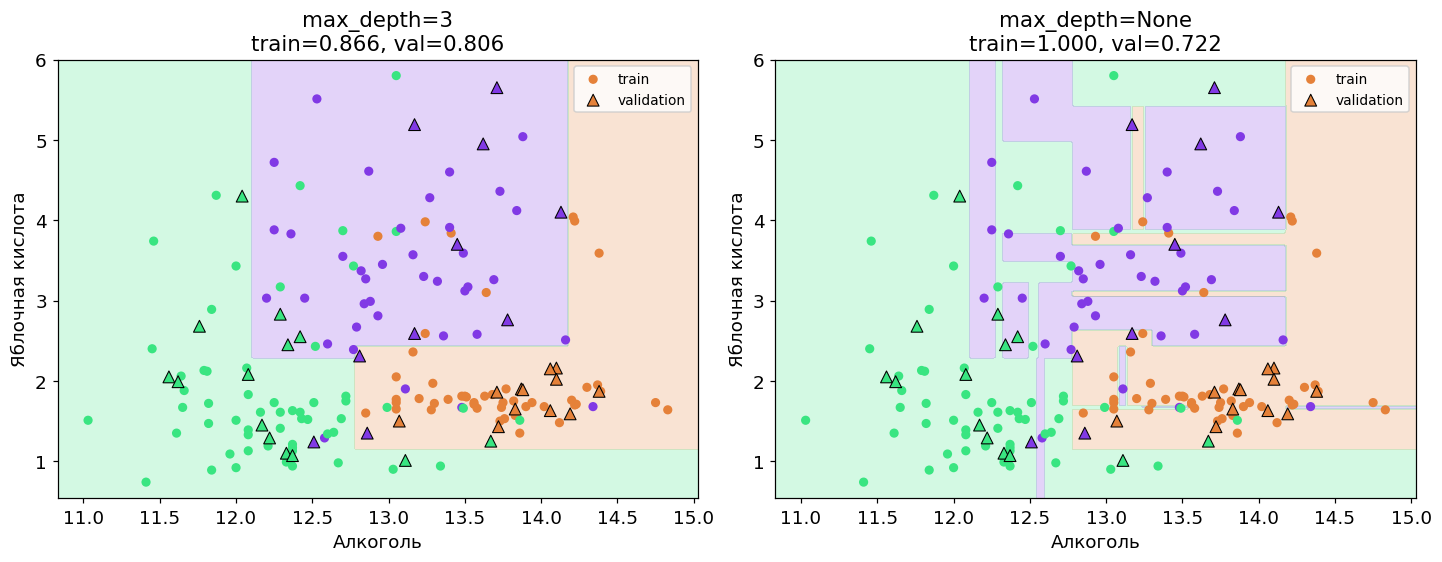

In [ ]:
wine = load_wine()
X_wine, y_wine = wine.data[:, :2], wine.target
X_train, X_valid, y_train, y_valid = train_test_split(
    X_wine, y_wine, test_size=0.2, stratify=y_wine, random_state=42
)

w1 = np.linspace(X_wine[:, 0].min() - 0.2, X_wine[:, 0].max() + 0.2, 250)
w2 = np.linspace(X_wine[:, 1].min() - 0.2, X_wine[:, 1].max() + 0.2, 250)
wx, wy = np.meshgrid(w1, w2)
wine_grid = np.c_[wx.ravel(), wy.ravel()]

# Одна функция для одинакового оформления всех сравнений.
def show_wine_tree(model, ax, title):
    z = model.predict(wine_grid).reshape(wx.shape)
    ax.contourf(wx, wy, z, levels=[-0.5, 0.5, 1.5, 2.5],
                cmap=class_cmap, alpha=0.22)
    ax.scatter(X_train[:, 0], X_train[:, 1], c=y_train,
               cmap=class_cmap, vmin=0, vmax=2, s=25, label="train")
    ax.scatter(X_valid[:, 0], X_valid[:, 1], c=y_valid,
               cmap=class_cmap, vmin=0, vmax=2, marker="^", s=60,
               edgecolor="black", linewidth=0.7, label="validation")
    ax.set_title(f"{title}\ntrain={model.score(X_train, y_train):.3f}, "
                 f"val={model.score(X_valid, y_valid):.3f}")
    ax.set_xlabel("Алкоголь")
    ax.set_ylabel("Яблочная кислота")
    ax.legend(fontsize=9)

fig, axes = plt.subplots(1, 2, figsize=(13, 5), constrained_layout=True)
for depth, ax in zip([3, None], axes):
    model = DecisionTreeClassifier(max_depth=depth, random_state=42)
    model.fit(X_train, y_train)
    show_wine_tree(model, ax, f"max_depth={depth}")
plt.show()

Сопоставьте числа над графиками. Какое дерево лучше запомнило train? Помогло ли это на validation? Где появились дополнительные маленькие области?

Это один фиксированный пример; ограничение глубины не обязано улучшать каждый результат. Мы используем validation для учебного сравнения настроек. В полноценном эксперименте выбранную модель затем проверяют на отдельном финальном тесте.

### 6. Небольшая практика

В следующей ячейке меняем только `DEPTH` и `MIN_LEAF`.

1. Запустите исходный вариант: `DEPTH=3`, `MIN_LEAF=1`.
2. Измените только глубину на `None`. Что произошло с train и validation?
3. Верните `DEPTH=3` и увеличьте `MIN_LEAF` до 5. Как изменились дерево и метрики? Объясните результат в одном-двух предложениях.

Наша задача — увидеть последствия ограничения сложности. Повышение validation accuracy в каждом запуске не требуется.

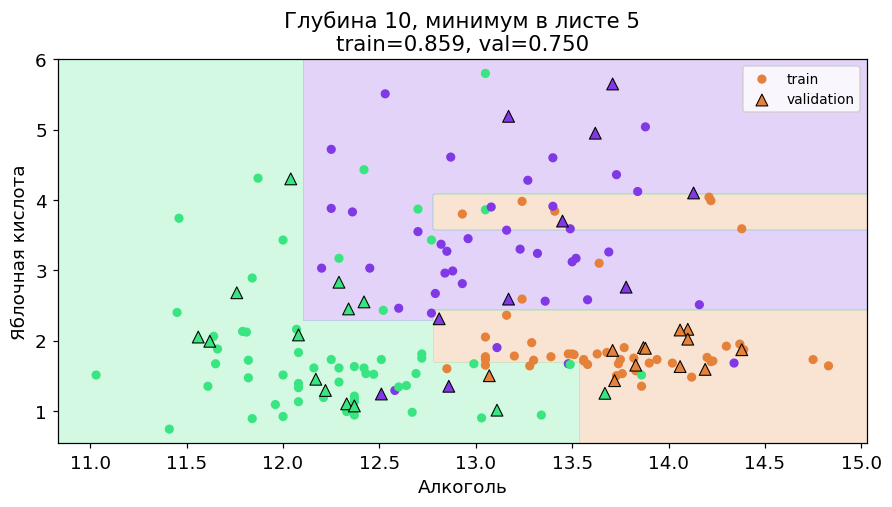

Число листьев: 15


In [ ]:
DEPTH = 10
MIN_LEAF = 5

practice_tree = DecisionTreeClassifier(
    max_depth=DEPTH, min_samples_leaf=MIN_LEAF, random_state=123456
)
practice_tree.fit(X_train, y_train)
fig, ax = plt.subplots(figsize=(8, 4.5), constrained_layout=True)
show_wine_tree(practice_tree, ax, f"Глубина {DEPTH}, минимум в листе {MIN_LEAF}")
plt.show()
print("Число листьев:", practice_tree.get_n_leaves())

### 7. Обсуждение вопросов

Обсудим три вопроса:

1. Что предсказывает лист с числовыми ответами $2,3,4$ при использовании MSE? А лист с метками классов $(1,1,2,2,2,2)$?
2. Почему при выборе разбиения недостаточно просто сложить неоднородности двух потомков?
3. Почему accuracy $=1$ на train не означает, что дерево готово к применению?

<details>
<summary>Ориентиры для обсуждения</summary>

1. В регрессии — среднее 3. В классификации — класс 2; его доля составляет $2/3$.
2. Потомки могут содержать разное число объектов, поэтому нужны веса по их размерам.
3. Дерево могло запомнить особенности и шум обучающих данных; нужна проверка на новых объектах.

</details>

**Основные идеи:** дерево задаёт правила; прогноз в листе зависит от задачи; критерий оценивает неоднородность, а $Q$ — её уменьшение. Ограничения сложности и проверка на отложенных данных помогают контролировать переобучение.

На следующем занятии обсудим, как объединять несколько деревьев, чтобы сделать прогнозы устойчивее.

## Часть II. Ансамбли деревьев

На предыдущих графиках отдельные деревья заметно меняли границы. Идея ансамбля — обучить несколько различающихся деревьев и объединить их прогнозы. В регрессии усредняем числа; в используемых ниже классификаторах `scikit-learn` усредняем вероятности:

$$
\large
\bar p_k(x)=\frac1B\sum_{b=1}^{B}p_k^{(b)}(x),
\qquad \widehat y(x)=\arg\max_k\bar p_k(x).
$$

$B$ — число деревьев, $p_k^{(b)}(x)$ — вероятность класса $k$ по дереву $b$. При чистых листьях такое усреднение совпадает с голосованием по меткам; в общем случае это разные процедуры.

### Чем отличаются три подхода

| Метод | Данные для каждого дерева | Признаки при разбиении | Выбор порога |
|---|---|---|---|
| Bagging деревьев | Bootstrap: выборка с возвращением | Все признаки в нашем примере | Лучший по критерию |
| Random Forest | Bootstrap в нашем примере | Новое случайное подмножество в каждой вершине | Лучший среди проверяемых признаков |
| Extra Trees | Вся обучающая выборка, `bootstrap=False` | Новое случайное подмножество в каждой вершине | Случайные пороги; выбираем лучший из предложенных |

В Extra Trees случайным является не весь выбор без оценки качества: случайно предлагают пороги, а затем сравнивают их по критерию. Bootstrap для Extra Trees можно включить отдельно.

Не путайте `max_features` у `BaggingClassifier` и у леса: в bagging подмножество задаётся **на целое дерево**, а у RF/Extra Trees — при поиске разбиения **в каждой вершине**. Ниже bagging получает все признаки, а оба леса используют `max_features="sqrt"`.

См. [bagging](https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.BaggingClassifier.html), [Random Forest](https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.RandomForestClassifier.html) и [Extra Trees](https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.ExtraTreesClassifier.html).

### Почему усреднение может помочь

Для фиксированного объекта обозначим прогноз дерева через $Z_b$. Для короткого расчёта предположим одинаковую дисперсию $\sigma^2$ и попарную корреляцию $\rho$. Случайность связана с обучающими данными и построением деревьев.

$$
\large
\begin{aligned}
\operatorname{Var}\!\left(\frac1B\sum_{b=1}^B Z_b\right)
&=\frac1{B^2}\left(\sum_b\operatorname{Var}(Z_b)
+2\sum_{b<c}\operatorname{Cov}(Z_b,Z_c)\right)\\[5pt]
&=\frac{B\sigma^2+B(B-1)\rho\sigma^2}{B^2}\\[5pt]
&=\rho\sigma^2+\frac{1-\rho}{B}\sigma^2.
\end{aligned}
$$

В первой сумме $B$ дисперсий; разных неупорядоченных пар $B(B-1)/2$, а перед суммой ковариаций стоит 2. Отсюда множитель $B(B-1)$.

При $\rho=0$ дисперсия среднего равна $\sigma^2/B$, а при $\rho=1$ усреднение ничего не меняет. Поэтому важно не только число деревьев, но и их различие. Случайность признаков и порогов может снизить корреляцию, но также меняет качество отдельных деревьев: универсального победителя среди трёх методов нет.

In [1]:
# новая настройка данных для второй части; предыдущие X/y не нужны.
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import make_moons
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import BaggingClassifier, RandomForestClassifier, ExtraTreesClassifier

X_ens, y_ens = make_moons(n_samples=600, noise=0.30, random_state=42) # создаем искусственный датасет (в форме полумесяцев), а шум помогает сделать задачу еще более сложной для модели
X_ens_train, X_ens_valid, y_ens_train, y_ens_valid = train_test_split(
    X_ens, y_ens, test_size=0.30, stratify=y_ens, random_state=42
)
B = 150
models = {
    "Одно дерево": DecisionTreeClassifier(random_state=42),
    "Bagging": BaggingClassifier(
        estimator=DecisionTreeClassifier(), n_estimators=B,
        bootstrap=True, max_samples=1.0, max_features=1.0,
        oob_score=True, random_state=42, n_jobs=-1,
    ),
    "Random Forest": RandomForestClassifier(
        n_estimators=B, max_features="sqrt", bootstrap=True,
        oob_score=True, random_state=42, n_jobs=-1,
    ),
    "Extra Trees": ExtraTreesClassifier(
        n_estimators=B, max_features="sqrt", bootstrap=False,
        random_state=42, n_jobs=-1,
    ),
}
rows = []
for name, model in models.items():
    model.fit(X_ens_train, y_ens_train)
    rows.append({
        "Модель": name,
        "Accuracy train": model.score(X_ens_train, y_ens_train),
        "Accuracy validation": model.score(X_ens_valid, y_ens_valid),
        "Accuracy OOB": getattr(model, "oob_score_", np.nan),
    })
comparison = pd.DataFrame(rows).set_index("Модель")
comparison.round(3).fillna("—")

,Accuracy train,Accuracy validation,Accuracy OOB
Модель,,,
Одно дерево,1.0,0.872,—
Bagging,1.0,0.889,0.91
Random Forest,1.0,0.883,0.912
Extra Trees,1.0,0.889,—


### Сравниваем результат

Сначала сравните train и validation: помогает ли усреднение на новых объектах? Затем сопоставьте числа с границами решений. На всех панелях одинаковые данные и шкала вероятности класса 1; точки — train, треугольники — validation. Чёрная линия соответствует вероятности 0.5.

Это учебное сравнение на одном разбиении, а не доказательство превосходства конкретного метода. Прочерк в OOB означает, что такая оценка для выбранной конфигурации не вычисляется. Ниже отдельно разберём, откуда она берётся.

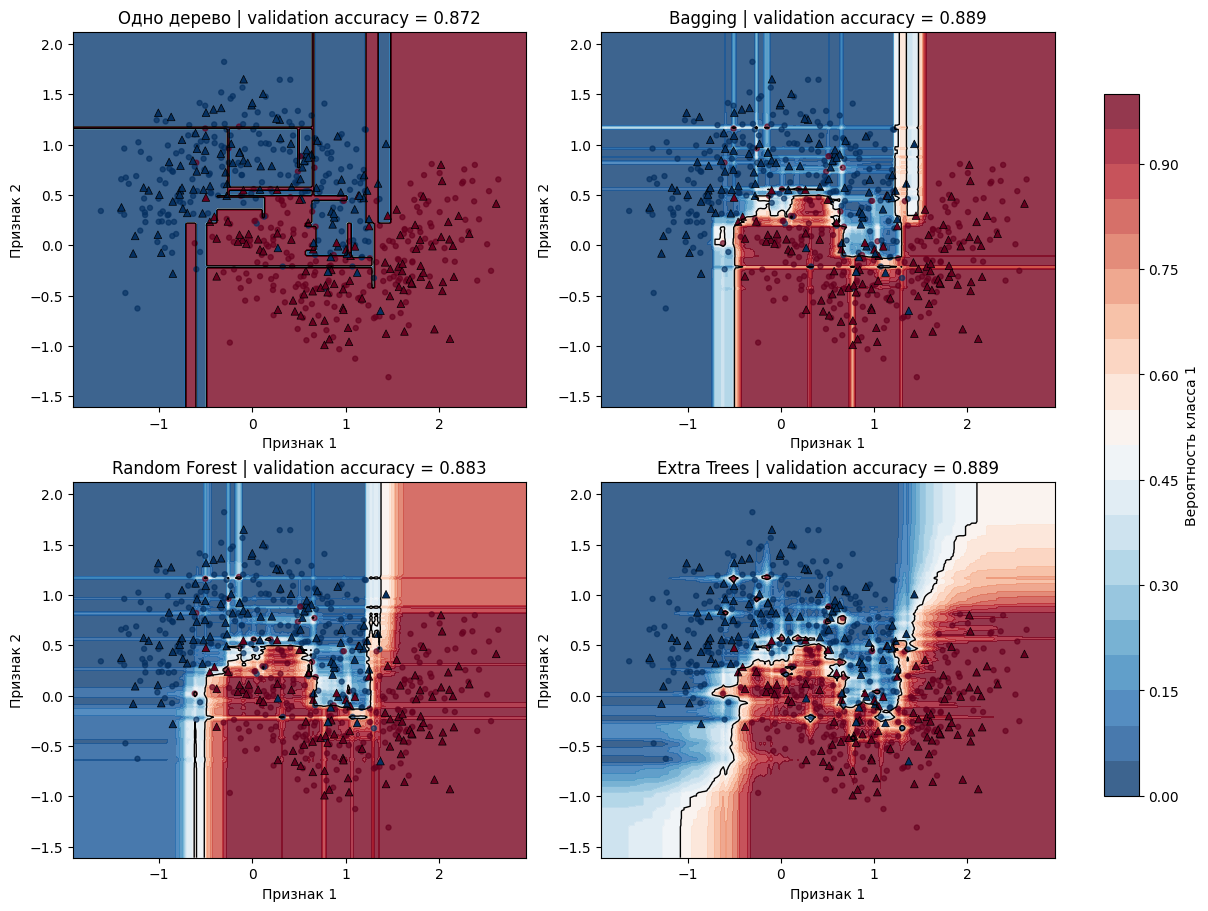

In [2]:
x1 = np.linspace(X_ens[:, 0].min() - 0.3, X_ens[:, 0].max() + 0.3, 220)
x2 = np.linspace(X_ens[:, 1].min() - 0.3, X_ens[:, 1].max() + 0.3, 220)
gx, gy = np.meshgrid(x1, x2)
grid = np.c_[gx.ravel(), gy.ravel()]
fig, axes = plt.subplots(2, 2, figsize=(12, 9), constrained_layout=True)
for ax, (name, model) in zip(axes.ravel(), models.items()):
    prob = model.predict_proba(grid)[:, 1].reshape(gx.shape)
    surface = ax.contourf(gx, gy, prob, levels=np.linspace(0, 1, 21),
                          cmap="RdBu_r", vmin=0, vmax=1, alpha=0.8)
    ax.contour(gx, gy, prob, levels=[0.5], colors="black", linewidths=1)
    ax.scatter(X_ens_train[:, 0], X_ens_train[:, 1], c=y_ens_train,
               cmap="RdBu_r", vmin=0, vmax=1, s=13, alpha=0.65)
    ax.scatter(X_ens_valid[:, 0], X_ens_valid[:, 1], c=y_ens_valid,
               cmap="RdBu_r", vmin=0, vmax=1, marker="^", s=30,
               edgecolor="black", linewidth=0.5)
    score = comparison.loc[name, "Accuracy validation"]
    ax.set_title(f"{name} | validation accuracy = {score:.3f}")
    ax.set_xlabel("Признак 1")
    ax.set_ylabel("Признак 2")
fig.colorbar(surface, ax=axes, label="Вероятность класса 1", shrink=0.85)
plt.show()

### OOB: прогнозируют только деревья, не видевшие объект

Bootstrap-выборка содержит $n$ случайных выборов **с возвращением** из $n$ обучающих объектов. Одни индексы повторяются, другие не попадают в неё. Для фиксированного объекта:

$$
\large
\mathbb P(\text{не выбран ни разу})
=\left(1-\frac1n\right)^n\approx e^{-1}\approx0.368.
$$

Один раз не выбрать объект можно с вероятностью $1-1/n$; выборов $n$, они независимы. Поэтому в среднем около 36.8% объектов остаются **out-of-bag** для отдельного дерева, а около 63.2% представлены хотя бы раз.

Для OOB-прогноза объекта усредняем только те деревья, в bootstrap-выборки которых он не попал. У разных объектов это разные подмножества деревьев. Проверим вручную на одном объекте из train; validation в этом расчёте не используется.

In [3]:
bag = models["Bagging"] # выбираем модель
n_train = len(X_ens_train)
samples = bag.estimators_samples_
first_sample = samples[0]
print(f"Первый bootstrap: {len(first_sample)} выборов из {n_train} объектов")
print(f"Уникальных объектов: {len(np.unique(first_sample))} "
      f"({len(np.unique(first_sample)) / n_train:.1%})")

i = 0  # индекс объекта внутри обучающей выборки
oob_ids = [b for b, indices in enumerate(samples) if i not in indices] # итерируемся по деревьям и смотрим, был ли там такой объект.
# Если нет - фиксируем то дерево, которое не получало наш объект для обучения. У нас таких 55 штук (см ниже)
oob_probabilities = [
    bag.estimators_[b].predict_proba(
        X_ens_train[i:i+1, bag.estimators_features_[b]] # просим сделать предикт для нашего объекта, при этом
        # мы обязаны передать дереву ровно тот же набор и порядок признаков, на которых это дерево училось
    )[0]
    for b in oob_ids # теперь итерируемся по 55 деревьям
]
manual_oob = np.mean(oob_probabilities, axis=0)
print(f"Объект {i}: OOB-деревьев {len(oob_ids)} из {B}")
print("Вероятности вручную:", np.round(manual_oob, 4))
print("Вероятности sklearn:", np.round(bag.oob_decision_function_[i], 4))
print("Истинный класс:", y_ens_train[i])

Первый bootstrap: 420 выборов из 420 объектов
Уникальных объектов: 262 (62.4%)
Объект 0: OOB-деревьев 55 из 150
Вероятности вручную: [0.9818 0.0182]
Вероятности sklearn: [0.9818 0.0182]
Истинный класс: 0


### Обсуждение пройденного

1. Почему `ExtraTreesClassifier(bootstrap=False)` всё равно строит разные деревья?
2. Почему `BaggingClassifier(max_features=0.5)` не превращается автоматически в Random Forest?
3. Почему OOB удобно для настройки, но после многократного выбора по OOB всё равно полезен отдельный финальный тест?

<details>
<summary>Ориентиры для обсуждения</summary>

1. Остаются случайный выбор признаков и случайные пороги.
2. В bagging признаки выбираются на дерево целиком; в RF — заново в каждой вершине.
3. Повторный выбор по одной оценке подстраивает решение под неё. OOB не становится независимым финальным тестом после такого подбора.

</details>